In [1]:
import os
FM100_DATA_DIR = r"/mnt/c/Users/zevaz/OneDrive/Escritorio/Metamers/FM100data"

print("Looking in:", FM100_DATA_DIR)
print("Files:", os.listdir(FM100_DATA_DIR))


Looking in: /mnt/c/Users/zevaz/OneDrive/Escritorio/Metamers/FM100data
Files: ['AllFM100results.csv', 'MET025.txt', 'MET025b.txt', 'MET030.txt', 'MET037a.txt', 'MET038a.txt', 'MET038b.txt', 'MET039.txt', 'MET039b.txt', 'MET040a.txt', 'MET040b.txt', 'MET041.txt', 'MET042.txt', 'MET043.txt', 'partINFO.csv', 'PDdata.txt', 'repeatedSessions.txt', 'repeatedSessionsPY.txt', 'scoresALL.csv', 'scoresHC_CVD_PR_DE.csv', 'scoresPD.csv']


In [2]:
from metamers.scores.FM100 import (
    load_FM100_raw,
    load_participant_info,
    identify_participant,
    FM100_TESwhole,
    compute_VKS_metrics,
    compute_PES,
    compute_TES_trays
)

import pandas as pd

# Load data
FM100 = load_FM100_raw()
info = load_participant_info()

# Process only first 5 participants
subset = FM100.iloc[:5]

results = []

for idx, row in subset.iterrows():

    # --- Extract ID and cap order ---
    raw_id = row.iloc[3]                 # column 3 = Reference
    caps   = row.iloc[16:101].to_numpy() # 85 caps

    # --- Identify participant ---
    meta = identify_participant(raw_id, info)

    # --- Compute TES ---
    TES, SRTES, err_vals = FM100_TESwhole(caps)

    # --- Compute VKS metrics ---
    vks = compute_VKS_metrics(caps)

    # --- Compute PES ---
    pes = compute_PES(caps)

    # --- Compute tray-level TES ---
    trays = compute_TES_trays(caps)

    # --- Collect everything into one dict ---
    results.append({
        "ValidID": meta["ValidID"],
        "Session": meta["Session"],
        "Group": meta["Group"],
        "Subgroup": meta["Subgroup"],
        "TES": TES,
        "SqrtTES": SRTES,
        "VKS_Angle": vks["Angle"],
        "VKS_MajRad": vks["MajRad"],
        "VKS_MinRad": vks["MinRad"],
        "VKS_Sindex": vks["Sindex"],
        "VKS_Cindex": vks["Cindex"],
        "PES_RG": pes["PES_RG"],
        "PES_BY": pes["PES_BY"],
        "PES_RG_sqrt": pes["PES_RG_sqrt"],
        "PES_BY_sqrt": pes["PES_BY_sqrt"],
        "TES_tray1": trays["TES_tray"][0],
        "TES_tray2": trays["TES_tray"][1],
        "TES_tray3": trays["TES_tray"][2],
        "TES_tray4": trays["TES_tray"][3],
        "TES_whole_from_trays": trays["TES_whole"]
    })

# Convert to DataFrame for easy viewing
df_results = pd.DataFrame(results)
print(df_results)


  ValidID  Session Group  Subgroup   TES   SqrtTES  VKS_Angle  VKS_MajRad  \
0  MET000        1   CTR       NaN  36.0  6.000000  52.656846    3.114723   
1  MET000        2   CTR       NaN  48.0  6.928203  59.315033    3.778649   
2  MET000        3   CTR       NaN  20.0  4.472136  54.065445    2.702969   
3  MET001        1   CTR       NaN  52.0  7.211103  60.267799    3.668340   
4  MET002        1   CTR       NaN  24.0  4.898979  68.658728    2.863246   

   VKS_MinRad  VKS_Sindex  VKS_Cindex  PES_RG  PES_BY  PES_RG_sqrt  \
0    2.553297    1.219883    1.233432    17.0    19.0     4.123106   
1    2.469445    1.530161    1.496347    14.0    34.0     3.741657   
2    2.227585    1.213407    1.070377     8.0    12.0     2.828427   
3    2.496324    1.469497    1.452665    20.0    31.0     4.472136   
4    2.250017    1.272544    1.133847     4.0    20.0     2.000000   

   PES_BY_sqrt  TES_tray1  TES_tray2  TES_tray3  TES_tray4  \
0     4.358899        0.0       16.0       20.0       

In [3]:
from metamers.scores.FM100 import load_FM100_raw, load_participant_info
from metamers.scores.plotting import extract_error_profile

FM100 = load_FM100_raw()
info  = load_participant_info()

row = FM100.iloc[0]  # first participant

profile = extract_error_profile(row, info, smooth=True, window=15)

print(profile["SubID"], profile["Session"], profile["Group"])
print(profile["errors_raw"])
print(profile["errors_smooth"])


MET000 1 CTR
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 2. 1. 1. 4. 3. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 2. 2. 0. 3.
 3. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.06666667 0.2        0.26666667 0.33333333 0.6
 0.8        0.8        0.8        0.86666667 0.93333333 1.
 1.06666667 1.06666667 1.06666667 1.06666667 1.         0.86666667
 0.8        0.86666667 0.73333333 0.53333333 0.73333333 0.93333333
 0.93333333 0.93333333 0.86666667 0.86666667 0.93333333 1.
 1.06666667 1.06666667 1.06666667 1.13333333 1.06666667 1.
 1.06666667 0.86666667 0.66666667 0.6        0.53333333 0.53333333
 0.46666667 0.4        0.33333333 0.26666667 0.26666667 0.26666667
 0.2        0.13333333 0.06666667 0.         

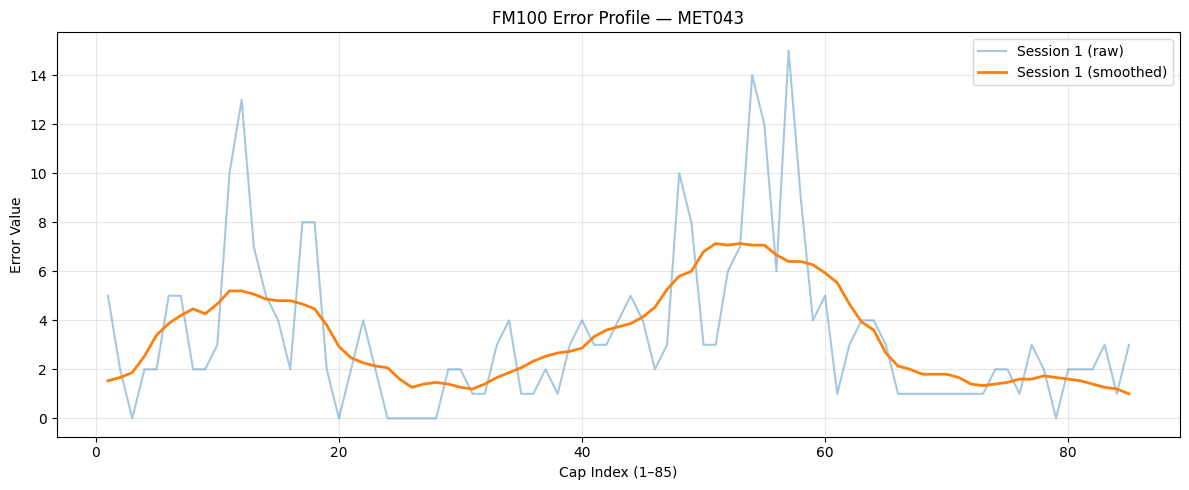

In [5]:
from metamers.scores.FM100 import load_FM100_raw, load_participant_info
from metamers.scores.plotting import plot_participant_errors

FM100 = load_FM100_raw()
info  = load_participant_info()

plot_participant_errors(FM100, info, subID="MET043", smooth=True, window=15)


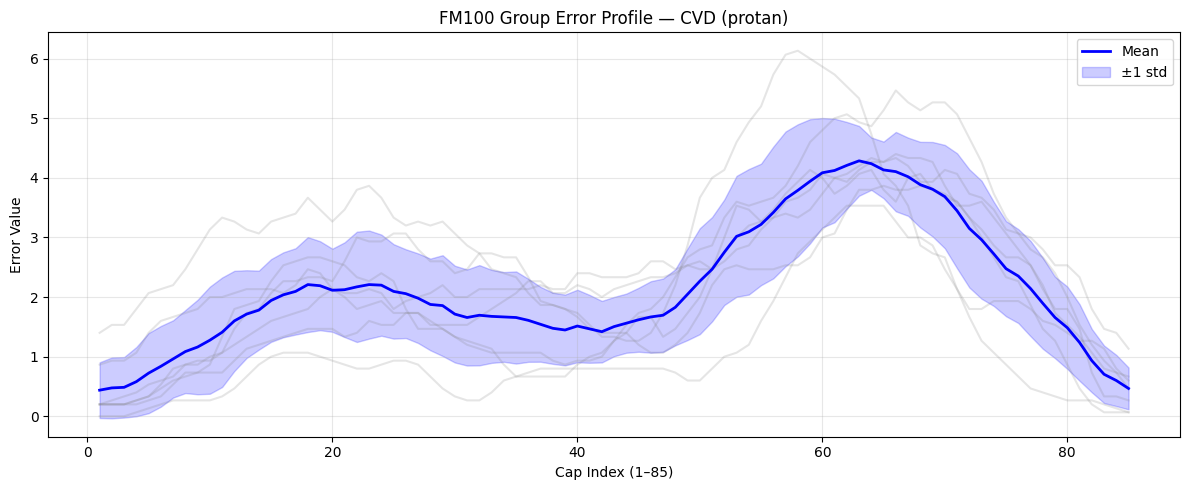

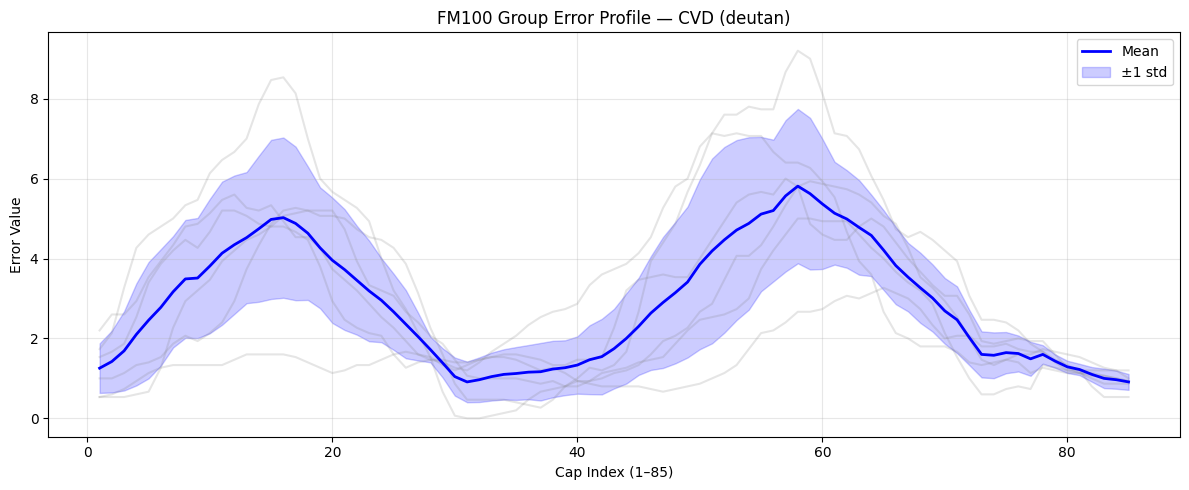

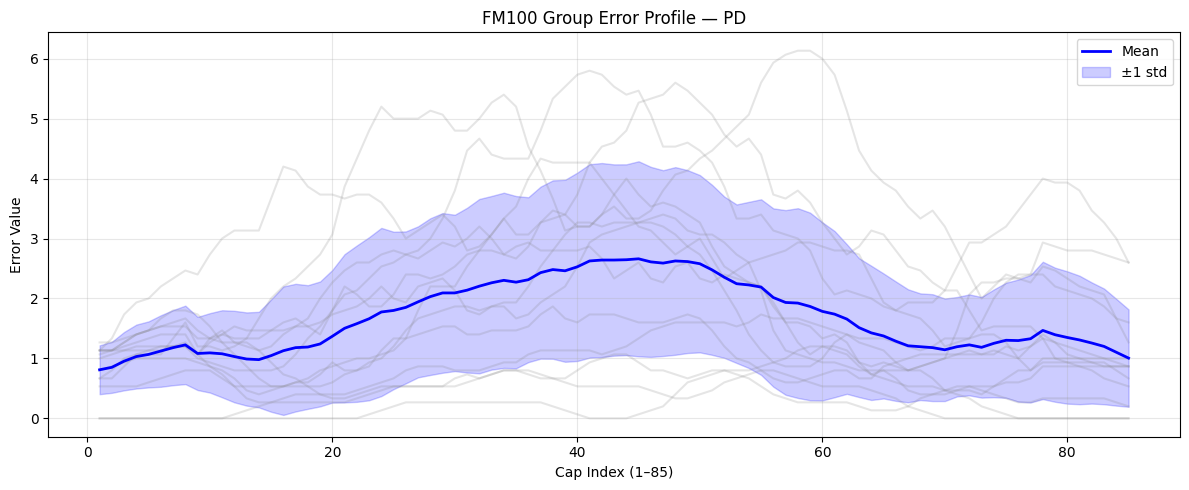

In [7]:
from metamers.scores.FM100 import load_FM100_raw, load_participant_info
from metamers.scores.plotting import plot_group_errors

FM100 = load_FM100_raw()
info  = load_participant_info()

plot_group_errors(FM100, info, group_name="CVD", subgroup_name="protan", smooth=True, window=15, show_individuals=True)
plot_group_errors(FM100, info, group_name="CVD", subgroup_name="deutan", smooth=True, window=15, show_individuals=True)

plot_group_errors(FM100, info, group_name="PD", smooth=True, window=15, show_individuals=True)



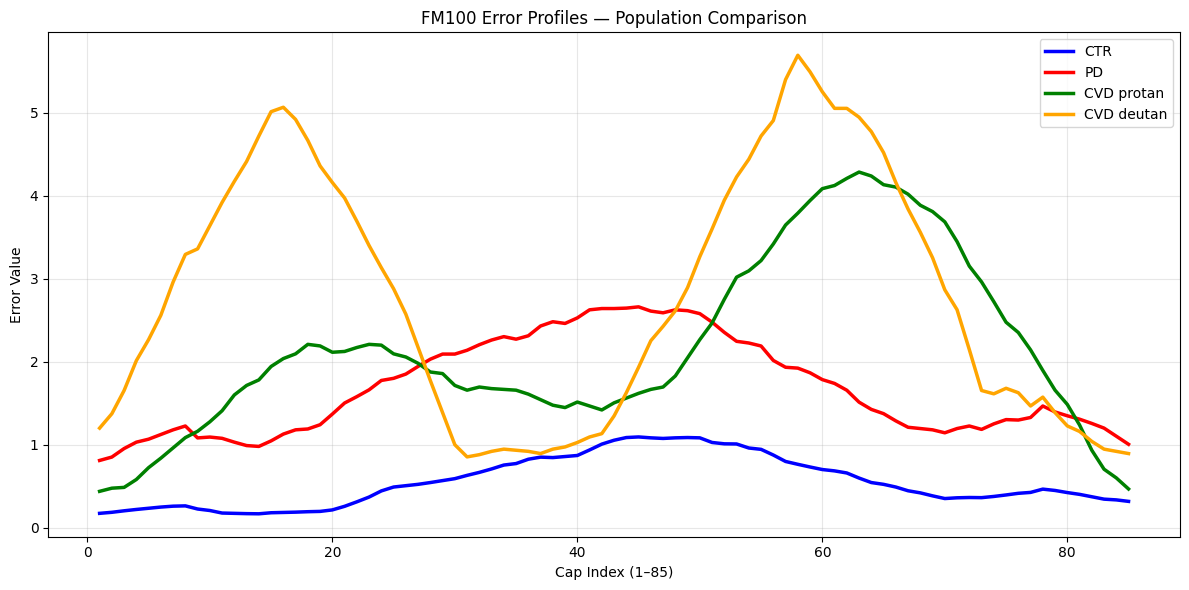

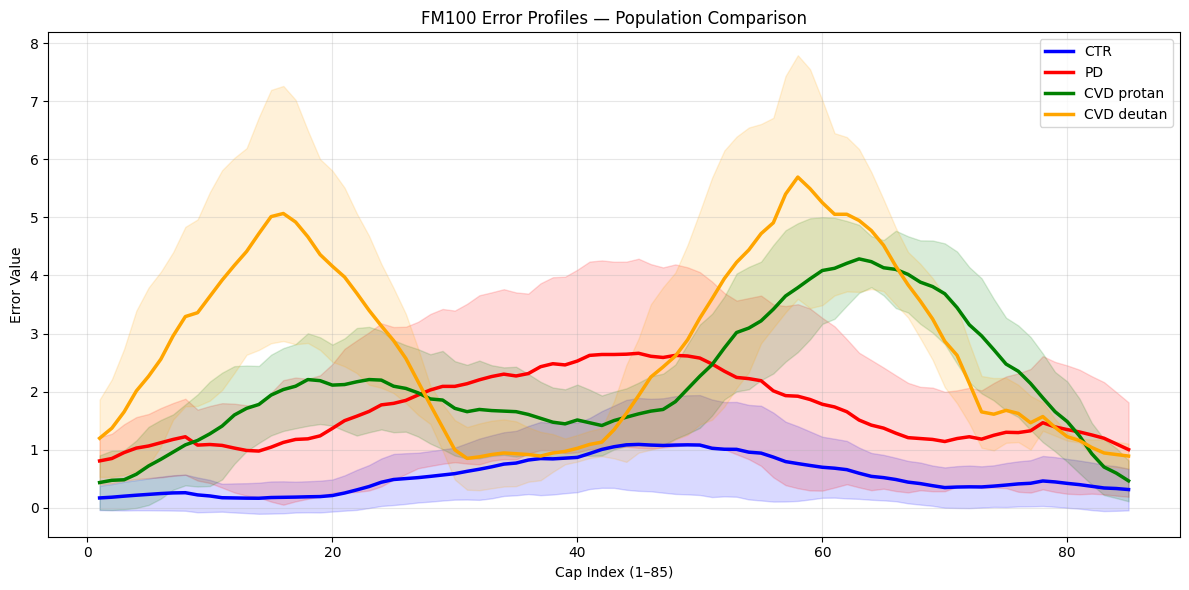

In [3]:
from metamers.scores.FM100 import load_FM100_raw, load_participant_info
from metamers.scores.plotting import plot_population_comparison, plot_population_comparison_shading

FM100 = load_FM100_raw()
info  = load_participant_info()

plot_population_comparison(FM100, info, smooth=True, window=15)
plot_population_comparison_shading(FM100, info, smooth=True, window=15)
